# Algoritmos - Actividad Guiada 1

Nombre: Emilio Moreno <br>
Link:  URL:https://github.com/Hiper1961/Algoritmos_Actividades_Guiadas-1-2-3.git


In [ ]:
#Librerias
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Torres de Hanoi con Divide y vencerás

In [ ]:
def Torres_Hanoi(N, desde, hasta):
  if N == 1:
    print("Lleva la ficha " ,desde , " hasta ", hasta )
  else:
    Torres_Hanoi(N-1, desde, 6-desde-hasta ) # mover lo n-1 al pivot auxiliar
    print("Lleva la ficha " ,desde , " hasta ", hasta ) # mover la ficha grande al destino
    Torres_Hanoi(N-1, 6-desde-hasta  , hasta ) # mover lo que se puso en el pivot auxiliar a el destino

Torres_Hanoi(3, 1 , 3)

Lleva la ficha  1  hasta  3
Lleva la ficha  1  hasta  2
Lleva la ficha  3  hasta  2
Lleva la ficha  1  hasta  3
Lleva la ficha  2  hasta  1
Lleva la ficha  2  hasta  3
Lleva la ficha  1  hasta  3


## Sucesión_de_Fibonacci

In [ ]:
#f0 = 0, f1= 1, f2 = f0 + f1 = 0 +1 = 1 , f3 = f2 + f1 = 1 + 1 = 2 .....
def Fibonacci (N:int):
  lista = [0, 1] # primeros número de la serie fibonnaci
  if N < 2:
    return lista[:N+1]
  for i in range(2, N+1):
        lista.append(lista[i-1] + lista[i-2])
  return lista
Fibonacci(5)

[0, 1, 1, 2, 3, 5]

## Devolución de cambio de Monedas por técnica voraz

In [ ]:
def Cambio_Monedas(N, lista_monedas):
  solucion = [0]*len(lista_monedas) # vector donde escribiremos cuantas monedas necesitamos
  for i, valor in enumerate(lista_monedas): #utilizamos enumerate para obtener el indice de la lista y el valor
    monedas = N // valor #cuantas monedas de ese valor necesito
    solucion[i] = monedas # guardo el valor
    N = N - valor*monedas
    if N == 0: # si ya con el cambio ya no tengo que seguir buscando mas monedas
      return solucion

Cambio_Monedas(20, [25, 10, 5, 1] )

[0, 2, 0, 0]

## N-Reinas por técnica de vueta atrás (Backtracking)


In [ ]:
def escribe(S):
  n = len(S)
  for x in range(n):
    print("")
    for i in range(n):
      if S[i] == x+1:
        print(" X " , end="")
      else:
        print(" - ", end="")


def es_prometedora(SOLUCION,etapa):
  #print(SOLUCION)
  #Si la solución tiene dos valores iguales no es valida => Dos reinas en la misma fila
  for i in range(etapa+1):
    #print("El valor " + str(SOLUCION[i]) + " está " +  str(SOLUCION.count(SOLUCION[i])) + " veces")
    if SOLUCION.count(SOLUCION[i]) > 1:
      return False

    #Verifica las diagonales
    for j in range(i+1, etapa +1 ):
      #print("Comprobando diagonal de " + str(i) + " y " + str(j))
      if abs(i-j) == abs(SOLUCION[i]-SOLUCION[j]) : return False
  return True



def reinas(N, solucion=[], etapa=0):
  if len(solucion) == 0:
      solucion=[0 for i in range(N)]

  for i in range(1, N+1):
    solucion[etapa] = i

    if es_prometedora(solucion, etapa):
      if etapa == N-1:
        print(solucion)
        #escribe(solucion)
        print()
      else:
        reinas(N, solucion, etapa+1)
    else:
      None

    solucion[etapa] = 0

reinas(4)

[2, 4, 1, 3]

[3, 1, 4, 2]



## Viaje por el rio. Programación dinámica

In [ ]:
TARIFAS = [
[0,5,4,3,999,999,999],
[999,0,999,2,3,999,11],
[999,999, 0,1,999,4,10],
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]



################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]
  RUTA = [ [""]*N for i in [""]*N]

  for i in range(0,N-1):
    RUTA[i][i] = i             #Para ir de i a i se "pasa por i"
    PRECIOS[i][i] = 0          #Para ir de i a i se se paga 0
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k          #Anota que para ir de i a j hay que pasar por k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA
################################################################


PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

#Determinar la ruta con Recursividad
def calcular_ruta(RUTA, desde, hasta):
  if desde == hasta:
    #print("Ir a :" + str(desde))
    return ""
  else:
    return str(calcular_ruta( RUTA, desde, RUTA[desde][hasta])) +  \
                ',' + \
                str(RUTA[desde][hasta] \
              )

print("\nLa ruta es:")
calcular_ruta(RUTA, 0,6)

PRECIOS
[0, 5, 4, 3, 8, 8, 11]
[9999, 0, 999, 2, 3, 8, 7]
[9999, 9999, 0, 1, 6, 4, 7]
[9999, 9999, 9999, 0, 5, 6, 9]
[9999, 9999, 9999, 9999, 0, 999, 4]
[9999, 9999, 9999, 9999, 9999, 0, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
[0, 0, 0, 0, 1, 2, 5]
['', 1, 1, 1, 1, 3, 4]
['', '', 2, 2, 3, 2, 5]
['', '', '', 3, 3, 3, 3]
['', '', '', '', 4, 4, 4]
['', '', '', '', '', 5, 5]
['', '', '', '', '', '', '']

La ruta es:


',0,2,5'

## Encontrar los puntos más cercanos

### Primer Intento: Fuerza Bruta

In [ ]:
def fuerza_bruta_1d(numeros):
    min_distancia = float('inf')
    par = ()
    n = len(numeros)

    for i in range(n):
        for j in range(i+1, n):
            distancia = abs(numeros[i] - numeros[j])
            if distancia < min_distancia:
                min_distancia = distancia
                par = (numeros[i], numeros[j])

    return par, min_distancia

numeros = [3403, 4537, 9089, 9746, 7259] # Conjunto de puntos
par_cercano, distancia_minima = fuerza_bruta_1d(numeros)
print(f'El par más cercano es {par_cercano} con una distancia de {distancia_minima}')


El par más cercano es (9089, 9746) con una distancia de 657


### Complejidad

El algoritmo de fuerza bruta compara cada elemento de la lista con todos los demás utilizando dos bucles anidados.Para calcular la complejidad temporal, analizamos el número de iteraciones:Cuando el bucle externo (i) está en el primer elemento, el bucle interno (j) realiza $N - 1$ comparaciones.En la siguiente vuelta hace $N - 2$, y así sucesivamente hasta llegar a $1$ sola comparación.Si sumamos todas las operaciones de esta secuencia decreciente, obtenemos una progresión aritmética:$$(N - 1) + (N - 2) + \dots + 2 + 1$$Aplicando la fórmula matemática para sumar esta secuencia, el resultado total de operaciones es:$$\frac{N \times (N - 1)}{2} = \frac{N^2 - N}{2}$$Al aplicar las reglas de la notación Big-O, se eliminan las constantes (el divisor entre 2) y los términos menores (el $-N$). Por lo tanto, el orden computacional final del algoritmo por fuerza bruta es cuadrático:$$\mathcal{O}(N^2)$$

### ¿ Se puede mejorar?
Sí, se puede mejorar drásticamente, pasando de una complejidad cuadrática $\mathcal{O}(N^2)$ a una complejidad lineal-logarítmica $\mathcal{O}(N \log N)$ utilizando la estrategia de Divide y Vencerás (o simplemente ordenando primero la lista).

### Segundo intento: Divide y Venceras

In [ ]:
def mif(lista):
    # Caso Base 1: Si la lista tiene 1 elemento o menos, no hay pares (retornamos infinito)
    if len(lista) <= 1:
        return float('inf'), ()

    # Caso Base 2: Si tiene exactamente 2 elementos, calculamos su distancia directa
    if len(lista) == 2:
        return lista[1] - lista[0], (lista[0], lista[1])

    # 3. Dividir a la mitad
    mitad = len(lista) // 2
    lista1 = lista[:mitad]
    lista2 = lista[mitad:]

    # 4. Conquistar: Llamadas recursivas GUARDANDO los resultados
    d_izq, par_izq = mif(lista1)
    d_der, par_der = mif(lista2)

    # Nos quedamos con el menor de los dos lados
    if d_izq < d_der:
      d_min, par = d_izq, par_izq
    else:
      d_min, par = d_der, par_der
    # 5. Frontera: Evaluamos el último de la izquierda y el primero de la derecha
    d_frontera = abs(lista1[-1] - lista2[0])

    if d_frontera < d_min:
      d_min = d_frontera
      par = (lista1[-1], lista2[0])
    # El resultado final es el menor entre lo que traían los lados y la frontera
    return d_min, par

# --- Bloque de prueba ---
numeros = [7, 15, 20, 50, 34, 80]
numeros.sort()
print(numeros)

print(f"El par más cercano es {mif(numeros)[1]} con una distancia de {mif(numeros)[0]}")

[7, 15, 20, 34, 50, 80]
El par más cercano es (15, 20) con una distancia de 5


### Complejidad
Al aplicar el algoritmo de Divide y Vencerás puro sobre una lista desordenada, en cada división recursiva se requiere ordenar o reorganizar los subarreglos para evaluar la frontera.
**Su relación de recurrencia es:**
$$T(n) = 2T\left(\frac{n}{2}\right) + \mathcal{O}(n \log n)$$
**Complejidad resultante:** Al resolver esta recurrencia, el coste de ordenar en cada nivel de profundidad da un orden temporal de $\mathcal{O}(N \log^2 n)$.

##¿Se puede mejorar?
Si realizando la ordenación de la lista de numeros desde el principo para eliminar la ordenación en cada paso recursivo. La combinación en la frontera pasa a costar un tiempo lineal simple $\mathcal{O}(1)$ o $\mathcal{O}(N)$.

**Nueva recurrencia optimizada:**
$$T(n) = 2T\left(\frac{n}{2}\right) + \mathcal{O}(1)$$

**Complejidad final mejorada:** Aplicando el Teorema Maestro, el algoritmo optimizado con el pre-ordenamiento se queda en $\mathcal{O}(N \log N)$.

### ALGORITMO 2D

In [ ]:
def distancia_euclidiana(p1, p2):
    return math.hypot(p1[0] - p2[0], p1[1] - p2[1])

def mas_cercanos_2d(puntos):
    # 1. Ordenar todos los puntos por X al inicio
    puntos_ordenados = sorted(puntos, key=lambda p: p[0])

    def resolver(arr):
        n = len(arr)

        # 2. Caso base: Si hay 3 o menos puntos, usamos fuerza bruta rápida
        if n <= 3:
            min_dist = float('inf')
            mejor_par = None
            for i in range(n):
                for j in range(i + 1, n):
                    d = distancia_euclidiana(arr[i], arr[j])
                    if d < min_dist:
                        min_dist = d
                        mejor_par = (arr[i], arr[j])
            return min_dist, mejor_par

        # 3. Dividir a la mitad
        mid = n // 2
        punto_medio_x = arr[mid][0]

        # Conquistar: llamadas recursivas para izquierda y derecha
        d_izq, par_izq = resolver(arr[:mid])
        d_der, par_der = resolver(arr[mid:])

        # Nos quedamos con el mejor entre izquierda y derecha
        if d_izq < d_der:
            min_dist = d_izq
            par = par_izq
        else:
            min_dist = d_der
            par = par_der

        # 4. La Franja (Revisar la frontera en 2D)
        # Filtramos los puntos cuya distancia en X a la línea de corte sea menor que min_dist
        franja = [p for p in arr if abs(p[0] - punto_medio_x) < min_dist]

        # Ordenamos la franja por la coordenada Y
        franja.sort(key=lambda p: p[1])

        # Comparamos cada punto con los siguientes en la franja (máximo 7)
        largo_franja = len(franja)
        for i in range(largo_franja):
            for j in range(i + 1, largo_franja):
                # Si la diferencia en Y ya es mayor que la distancia mínima, rompemos el ciclo
                if (franja[j][1] - franja[i][1]) >= min_dist:
                    break

                d = distancia_euclidiana(franja[i], franja[j])
                if d < min_dist:
                    min_dist = d
                    par = (franja[i], franja[j])

        return min_dist, par

    return resolver(puntos_ordenados)

# --- Bloque de prueba en 2D ---
mis_puntos = [(2, 3), (12, 30), (40, 50), (5, 1), (12, 10), (3, 4)]
distancia, par_cercano = mas_cercanos_2d(mis_puntos)

print(f"El par más cercano en 2D es {par_cercano} con una distancia de {distancia:.2f}")

El par más cercano en 2D es ((2, 3), (3, 4)) con una distancia de 1.41


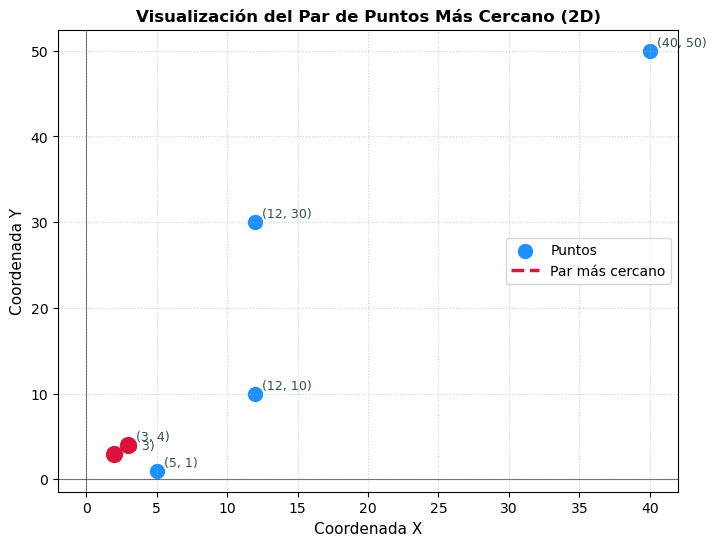

In [ ]:
# Visualización
def dibujar_par_cercano(puntos, par_cercano):
    # 1. Separar las coordenadas X e Y de todos los puntos
    x = [p[0] for p in puntos]
    y = [p[1] for p in puntos]

    # 2. Configurar el tamaño de la gráfica
    plt.figure(figsize=(8, 6))

    # 3. Dibujar todos los puntos normales en azul
    plt.scatter(x, y, color='dodgerblue', s=100, label='Puntos')

    # 4. Ponerle el numerito de la coordenada a cada punto para ubicarnos
    for p in puntos:
        plt.text(p[0] + 0.5, p[1] + 0.5, f"({p[0]}, {p[1]})", fontsize=9, color='darkslategray')

    # 5. Si encontramos un par cercano, lo resaltamos con una línea roja
    if par_cercano:
        p1, p2 = par_cercano
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color='crimson', linestyle='--', linewidth=2.5, label='Par más cercano')
        # Destacar los dos puntos ganadores en rojo
        plt.scatter([p1[0], p2[0]], [p1[1], p2[1]], color='crimson', s=130, zorder=5)

    # 6. Estética de la gráfica
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    plt.axvline(0, color='black', linewidth=0.8, alpha=0.5)
    plt.xlabel('Coordenada X', fontsize=11)
    plt.ylabel('Coordenada Y', fontsize=11)
    plt.title('Visualización del Par de Puntos Más Cercano (2D)', fontsize=12, fontweight='bold')
    plt.legend()
    plt.show()

# --- Ejemplo de cómo usarlo junto con tu función ---
mis_puntos = [(2, 3), (12, 30), (40, 50), (5, 1), (12, 10), (3, 4)]
distancia, par = mas_cercanos_2d(mis_puntos)
dibujar_par_cercano(mis_puntos, par)

### ALGORITMO 3D

In [ ]:
def distancia_euclidiana_3d(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def mas_cercanos_3d(puntos):
    # 1. Ordenar todos los puntos por X al inicio
    puntos_ordenados = sorted(puntos, key=lambda p: p[0])

    def resolver(arr):
        n = len(arr)

        # 2. Caso base: Si hay 3 o menos puntos, usamos fuerza bruta rápida
        if n <= 3:
            min_dist = float('inf')
            mejor_par = None
            for i in range(n):
                for j in range(i + 1, n):
                    d = distancia_euclidiana_3d(arr[i], arr[j])
                    if d < min_dist:
                        min_dist = d
                        mejor_par = (arr[i], arr[j])
            return min_dist, mejor_par

        # 3. Dividir a la mitad
        mid = n // 2
        punto_medio_x = arr[mid][0]

        # Conquistar: llamadas recursivas para izquierda y derecha
        d_izq, par_izq = resolver(arr[:mid])
        d_der, par_der = resolver(arr[mid:])

        # Nos quedamos con el mejor entre izquierda y derecha
        if d_izq < d_der:
            min_dist = d_izq
            par = par_izq
        else:
            min_dist = d_der
            par = par_der

        # 4. La Franja en 3D (Filtramos por X y luego ordenamos por Y y Z)
        franja = [p for p in arr if abs(p[0] - punto_medio_x) < min_dist]
        franja.sort(key=lambda p: p[1])

        # Comparamos en la franja
        largo_franja = len(franja)
        for i in range(largo_franja):
            for j in range(i + 1, largo_franja):
                if (franja[j][1] - franja[i][1]) >= min_dist:
                    break

                d = distancia_euclidiana_3d(franja[i], franja[j])
                if d < min_dist:
                    min_dist = d
                    par = (franja[i], franja[j])

        return min_dist, par

    return resolver(puntos_ordenados)

# --- Bloque de prueba en 3D ---
puntos_3d = [(1, 2, 3), (5, 8, 9), (2, 3, 4), (20, 25, 30), (5, 8, 10)]
distancia, par = mas_cercanos_3d(puntos_3d)

print(f"El par más cercano en 3D es {par} con una distancia de {distancia:.2f}")

El par más cercano en 3D es ((5, 8, 9), (5, 8, 10)) con una distancia de 1.00


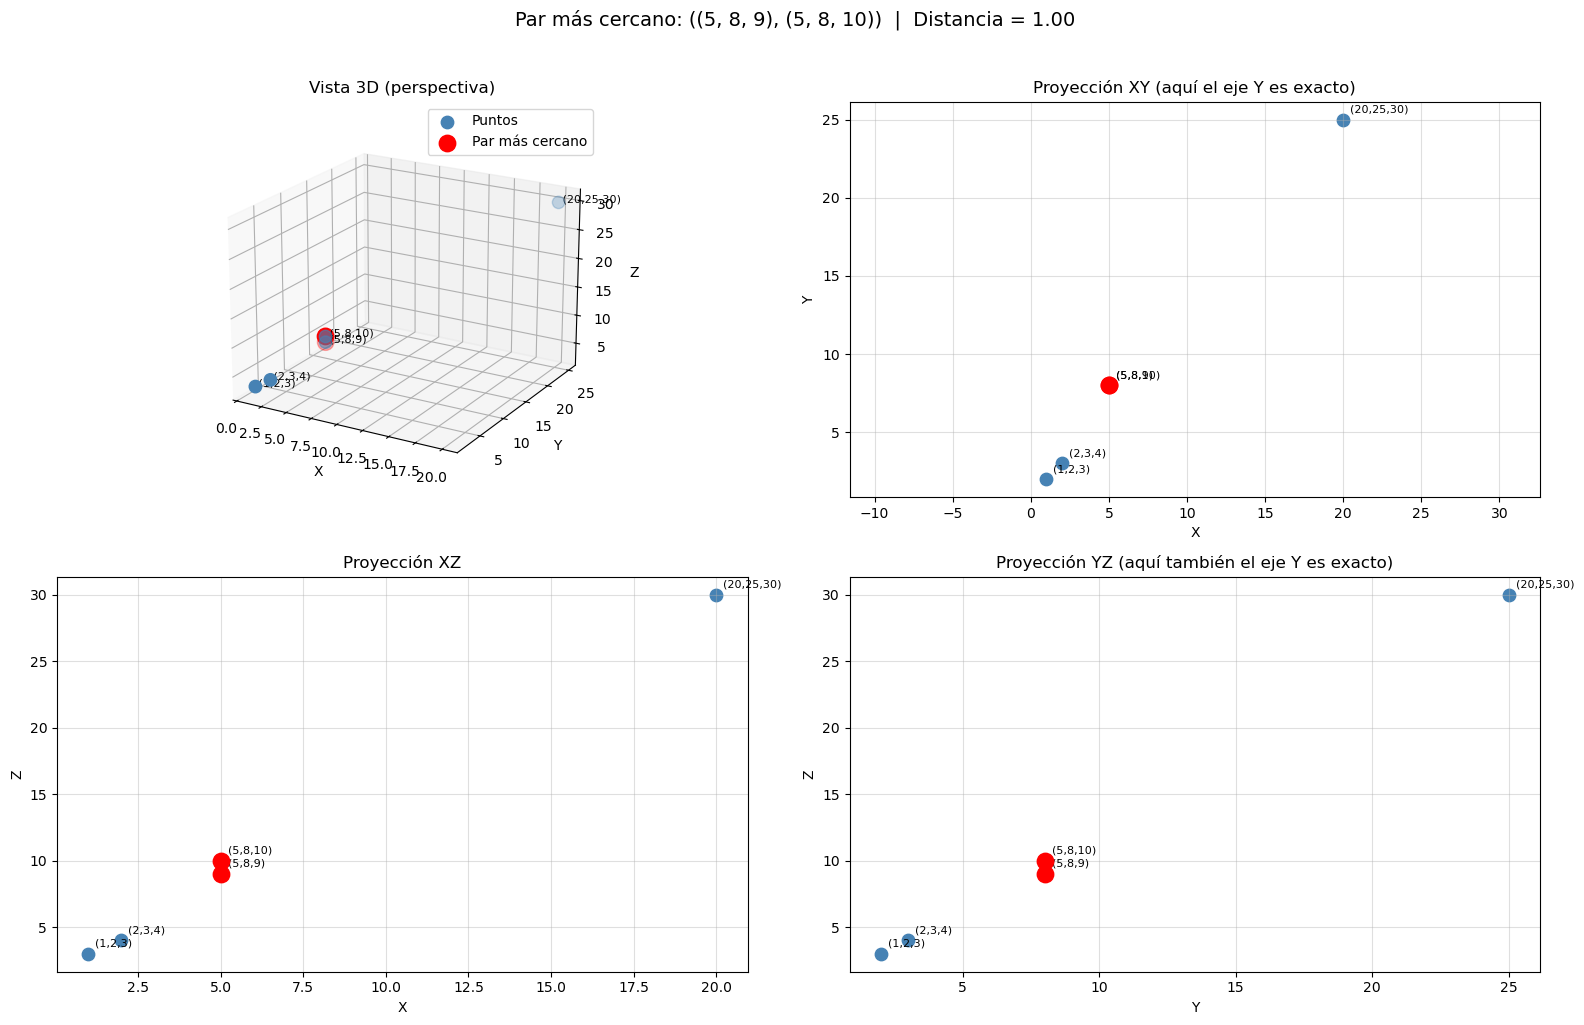

In [ ]:
#Visualización
# ===================== FIGURA COMPLETA =====================
fig = plt.figure(figsize=(16, 10))

# ----- 1. Gráfico 3D -----
ax3d = fig.add_subplot(2, 2, 1, projection='3d')

xs, ys, zs = zip(*puntos_3d)
ax3d.scatter(xs, ys, zs, c='steelblue', s=80, label='Puntos')

p1, p2 = par
ax3d.scatter([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
             c='red', s=140, label='Par más cercano', zorder=5)
ax3d.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], 'r--', lw=2.5)

for x, y, z in puntos_3d:
    ax3d.text(x, y, z, f' ({x},{y},{z})', fontsize=8)

ax3d.set_xlabel('X')
ax3d.set_ylabel('Y')
ax3d.set_zlabel('Z')
ax3d.set_title('Vista 3D (perspectiva)')
ax3d.view_init(elev=20, azim=-60)
ax3d.legend()

# ----- 2. Proyección XY (aquí se ve perfecto el eje Y) -----
ax_xy = fig.add_subplot(2, 2, 2)
ax_xy.scatter(xs, ys, c='steelblue', s=80)
ax_xy.scatter([p1[0], p2[0]], [p1[1], p2[1]], c='red', s=140, zorder=5)
ax_xy.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r--', lw=2)

for x, y, z in puntos_3d:
    ax_xy.annotate(f'({x},{y},{z})', (x, y), textcoords="offset points", xytext=(5,5), fontsize=8)

ax_xy.set_xlabel('X')
ax_xy.set_ylabel('Y')
ax_xy.set_title('Proyección XY (aquí el eje Y es exacto)')
ax_xy.grid(True, alpha=0.4)
ax_xy.set_aspect('equal', adjustable='datalim')

# ----- 3. Proyección XZ -----
ax_xz = fig.add_subplot(2, 2, 3)
ax_xz.scatter(xs, zs, c='steelblue', s=80)
ax_xz.scatter([p1[0], p2[0]], [p1[2], p2[2]], c='red', s=140, zorder=5)
ax_xz.plot([p1[0], p2[0]], [p1[2], p2[2]], 'r--', lw=2)

for x, y, z in puntos_3d:
    ax_xz.annotate(f'({x},{y},{z})', (x, z), textcoords="offset points", xytext=(5,5), fontsize=8)

ax_xz.set_xlabel('X')
ax_xz.set_ylabel('Z')
ax_xz.set_title('Proyección XZ')
ax_xz.grid(True, alpha=0.4)

# ----- 4. Proyección YZ -----
ax_yz = fig.add_subplot(2, 2, 4)
ax_yz.scatter(ys, zs, c='steelblue', s=80)
ax_yz.scatter([p1[1], p2[1]], [p1[2], p2[2]], c='red', s=140, zorder=5)
ax_yz.plot([p1[1], p2[1]], [p1[2], p2[2]], 'r--', lw=2)

for x, y, z in puntos_3d:
    ax_yz.annotate(f'({x},{y},{z})', (y, z), textcoords="offset points", xytext=(5,5), fontsize=8)

ax_yz.set_xlabel('Y')
ax_yz.set_ylabel('Z')
ax_yz.set_title('Proyección YZ (aquí también el eje Y es exacto)')
ax_yz.grid(True, alpha=0.4)

plt.suptitle(f'Par más cercano: {par}  |  Distancia = {distancia:.2f}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()